# Course 3 — Reinforcement Learning & Deep Q-Networks (DQN)

Concepts: MDP formulation, Value Iteration, Deep Q-Networks, Replay Buffer, Target Network.


## 1. Continuous Tracking Environment Definition


In [6]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import deque

tf.random.set_seed(42)
rng = np.random.default_rng(42)

class ContinuousEnv:
    """1D continuous state tracking environment [position, velocity]."""
    def __init__(self):
        self.state = np.zeros(2, dtype=np.float32)
        
    def reset(self):
        self.state[0] = rng.uniform(-0.5, 0.5)
        self.state[1] = rng.uniform(-0.1, 0.1)
        return self.state.copy()
        
    def step(self, action):
        a = -0.05 if action == 0 else (0.05 if action == 2 else 0.0)
        v = np.clip(self.state[1] + a, -0.2, 0.2)
        x = np.clip(self.state[0] + v, -1.0, 1.0)
        self.state = np.array([x, v], dtype=np.float32)
        
        reward = 1.0 - 5.0 * (x ** 2) - 2.0 * (v ** 2)
        done = False
        if abs(x) > 0.8:
            done = True
            reward = -10.0
        elif abs(x) < 0.05 and abs(v) < 0.05:
            done = True
            reward = 10.0
            
        return self.state.copy(), reward, done


## 2. Experience Replay Buffer


In [7]:
class ReplayBuffer:
    def __init__(self, capacity=1000):
        self.buffer = deque(maxlen=capacity)
        
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        indices = rng.choice(len(self.buffer), batch_size, replace=False)
        states, actions, rewards, next_states, dones = [], [], [], [], []
        for idx in indices:
            s, a, r, ns, d = self.buffer[idx]
            states.append(s)
            actions.append(a)
            rewards.append(r)
            next_states.append(ns)
            dones.append(d)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int32),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))


## 3. Deep Q-Network Agent Training Loop


In [8]:
def build_q_network():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(2,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(3, activation="linear")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mse")
    return model

env = ContinuousEnv()
buffer = ReplayBuffer(capacity=2000)

q_net = build_q_network()
target_net = build_q_network()
target_net.set_weights(q_net.get_weights())

gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.985
epsilon_min = 0.1
batch_size = 32
tau = 0.1

n_episodes = 100
dqn_rewards = []

print("Training Deep Q-Network (DQN) Agent:")
for ep in range(n_episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        if rng.random() < epsilon:
            action = rng.integers(3)
        else:
            q_values = q_net(state[np.newaxis, :]).numpy()
            action = np.argmax(q_values[0])
            
        next_state, reward, done = env.step(action)
        buffer.add(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        if len(buffer.buffer) > batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)
            target_q_next = target_net(next_states).numpy()
            max_target_q = np.max(target_q_next, axis=1)
            targets = rewards + gamma * max_target_q * (1.0 - dones)
            
            q_targets = q_net(states).numpy()
            q_targets[np.arange(batch_size), actions] = targets
            
            q_net.train_on_batch(states, q_targets)
            
            q_weights = q_net.get_weights()
            t_weights = target_net.get_weights()
            new_weights = [tau * qw + (1.0 - tau) * tw for qw, tw in zip(q_weights, t_weights)]
            target_net.set_weights(new_weights)
            
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    dqn_rewards.append(total_reward)
    if (ep + 1) % 25 == 0:
        print(f"  Episode {ep+1:3d}  Total Reward: {total_reward:6.1f}  Epsilon: {epsilon:.3f}")

print(f"DQN Training Complete. Avg Reward (Last 10 Ep): {np.mean(dqn_rewards[-10:]):.2f}")


Training Deep Q-Network (DQN) Agent:
  Episode  25  Total Reward:    3.2  Epsilon: 0.685
  Episode  50  Total Reward:   31.6  Epsilon: 0.470
  Episode  75  Total Reward:    8.2  Epsilon: 0.322
  Episode 100  Total Reward:   89.7  Epsilon: 0.221
DQN Training Complete. Avg Reward (Last 10 Ep): 35.87


## 4. Learning Curve Plotting


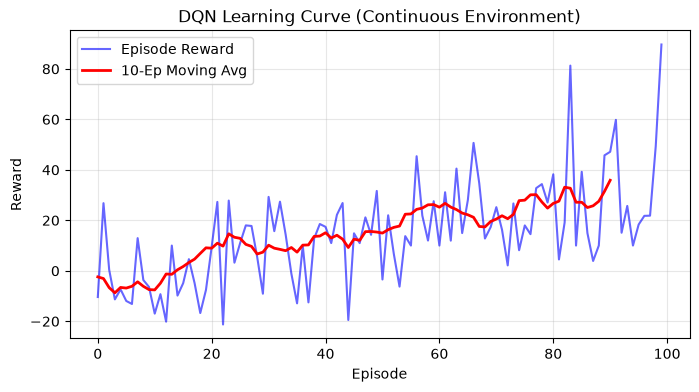

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(dqn_rewards, "b-", alpha=0.6, label="Episode Reward")
plt.plot(np.convolve(dqn_rewards, np.ones(10)/10, mode="valid"), "r-", linewidth=2, label="10-Ep Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Learning Curve (Continuous Environment)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Key Takeaways


In [10]:
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • MDP: (S, A, P, R, γ) — State, Action, Transition, Reward    ║
║ • Q-Learning: learns state-action values Q(s,a)               ║
║ • DQN: uses Neural Networks to approximate Q(s,a)             ║
║ • Experience Replay breaks correlation between sequential samples║
║ • Target Network stabilizes Q-learning target updates          ║
╚════════════════════════════════════════════════════════════════╝
""")



╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • MDP: (S, A, P, R, γ) — State, Action, Transition, Reward    ║
║ • Q-Learning: learns state-action values Q(s,a)               ║
║ • DQN: uses Neural Networks to approximate Q(s,a)             ║
║ • Experience Replay breaks correlation between sequential samples║
║ • Target Network stabilizes Q-learning target updates          ║
╚════════════════════════════════════════════════════════════════╝

